# Medium Circle Net VisualTCAV analysis

In [1]:
import sys, os, csv
import numpy as np
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path(os.path.abspath(''))
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from model.model_dylan import FlexibleTNet
from VisualTCAV_pytorch import Model, LocalVisualTCAV, GlobalVisualTCAV


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')

METHOD_CAV = "classifier"
CONCEPTS = ['circle_full', 'cross_full', 'square_full', 'circle_half_top', 'square_corner_bl', 'cross_arm_right']
LAYERS = []

/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/dlc/VisualTCAV
Device: cuda


In [2]:
STAGES = [
    {"conv": [8], "fc": [32], "name": "Stage 1"},
    {"conv": [16, 32], "fc": [64], "name": "Stage 2"},
    {"conv": [16, 32, 64], "fc": [128, 64], "name": "Stage 3"},
    {"conv": [25, 35, 50], "fc": [256, 128], "name": "Stage 4"},
    {"conv": [25, 35, 50, 75], "fc": [500, 250], "name": "Stage 5"},
    {"conv": [25, 35, 50, 75, 125], "fc": [500, 250, 50], "name": "Stage 6"},
]

def find_matching_stage(state_dict):
    conv_indices = set()
    for key in state_dict.keys():
        if "conv_layers" in key:
            parts = key.split('.')
            conv_indices.add(int(parts[1]))
    num_conv_layers = len(conv_indices)

    fc0_weight = state_dict.get("fc_layers.0.0.weight")
    in_features = fc0_weight.shape[1] if fc0_weight is not None else None

    for stage in STAGES:
        if len(stage["conv"]) == num_conv_layers:
            last_conv_key = f"conv_layers.{num_conv_layers-1}.0.weight"
            if state_dict[last_conv_key].shape[0] == stage["conv"][-1]:
                return stage
                
    raise ValueError("Could not find a matching stage configuration for this weight file.")

def load_flexible_model(weight_path, device='cpu'):
    state_dict = torch.load(weight_path, map_location=device, weights_only=True)
    config = find_matching_stage(state_dict)
    print(f"-> Detected: {config['name']}")

    model = FlexibleTNet(
        num_channels=1,
        num_classes=1,
        conv_channels=config["conv"],
        fc_layers=config["fc"],
        size_img=128,
        do_sigmoid=True
    )

    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

weights_dir = 'weights_circle/'
filename = 'circle_medium.pth'

path = os.path.join(weights_dir, filename)

nn_model = load_flexible_model(path)


-> Detected: Stage 4


In [3]:

def preprocess_grayscale(imgs):
    return imgs.astype(np.float32) / 255.0

vtcav_model = Model(
    model_name='FlexNet_CircleMedium',
    graph_path_filename=nn_model,           
    label_path_filename=['Circle present', 'Circle absent'],  
    preprocessing_function=preprocess_grayscale,
    binary_classification=True,
    max_examples=500,
    image_shape=[128, 128, 1],              
)


print(f'Model: {vtcav_model.model_name}')
print(f'Image shape: {vtcav_model.image_shape}')
print(f'Binary: {vtcav_model.binary_classification}')

Model: FlexNet_CircleMedium
Image shape: [128, 128, 1]
Binary: True


In [4]:
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
TEST_IMAGES_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val')

print(f'Concepts dir: {CONCEPTS_DIR}')
print(f'Test images dir: {TEST_IMAGES_DIR}')
print(f'Concept folders: {sorted(os.listdir(CONCEPTS_DIR))}')

Concepts dir: /home/dlc/VisualTCAV/data/concepts
Test images dir: /home/dlc/VisualTCAV/data/aixi_shape/val
Concept folders: ['.DS_Store', '__MACOSX', 'blue', 'blue.zip', 'braided', 'chequered', 'circle_full', 'circle_half_bottom', 'circle_half_left', 'circle_half_right', 'circle_half_top', 'circle_quarter_bl', 'circle_quarter_br', 'circle_quarter_tl', 'circle_quarter_tr', 'cross_arm_bottom', 'cross_arm_horizontal', 'cross_arm_left', 'cross_arm_right', 'cross_arm_top', 'cross_arm_vertical', 'cross_full', 'dotted', 'forest_floor', 'forest_floor.zip', 'frekeled', 'random_0', 'random_1', 'random_2', 'random_3', 'random_pool', 'random_pool_2', 'random_pool_3', 'random_pool_4', 'spiralled', 'square_corner_bl', 'square_corner_br', 'square_corner_tl', 'square_corner_tr', 'square_edge_bottom', 'square_edge_left', 'square_edge_right', 'square_edge_top', 'square_full', 'square_half_bottom', 'square_half_left', 'square_half_right', 'square_half_top', 'stripped']


Loaded metadata for indices: 1 and 120


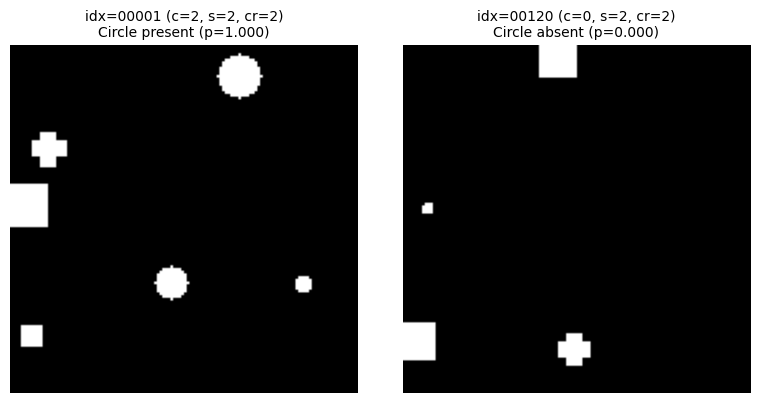

Image 1: 00001.png
Image 2: 00120.png


In [5]:


TARGET_IDX_WITH = 1   
TARGET_IDX_WITHOUT = 120 

val_csv = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val' / 'dades.csv'
val_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val'

with open(val_csv) as f:
    rows = list(csv.DictReader(f, delimiter=';'))


def get_metadata_for_idx(target_idx, csv_rows):
    for r in csv_rows:
        if int(r['']) == target_idx:
            return (target_idx, int(r['c']), int(r['s']), int(r['cr']))
    raise ValueError(f"Index {target_idx} not found in CSV.")


img_with = get_metadata_for_idx(TARGET_IDX_WITH, rows)
img_without = get_metadata_for_idx(TARGET_IDX_WITHOUT, rows)

print(f"Loaded metadata for indices: {img_with[0]} and {img_without[0]}")


img_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

nn_model.to(DEVICE)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (idx, c, s, cr) in zip(axes, [img_with, img_without]):
    img = Image.open(val_dir / f'{idx:05d}.png')
    
    t = img_transform(img.convert('L')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = nn_model(t).item()
        
    ax.imshow(np.array(img), cmap='gray')
    label = 'Circle present' if p > 0.5 else 'Circle absent'
    ax.set_title(f'idx={idx:05d} (c={c}, s={s}, cr={cr})\n{label} (p={p:.3f})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Image 1: {img_with[0]:05d}.png')
print(f'Image 2: {img_without[0]:05d}.png')

TCAV device: cpu
Circle present: torch.Size([200, 1, 128, 128])
Circle absent:  torch.Size([200, 1, 128, 128])

[1] Running TCAV: circle_full vs randoms...


/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/captum/concept/_core/tcav.py:325: UserWarning: Using default classifier for TCAV which keeps input both train and test datasets in the memory. Consider defining your own classifier that doesn't rely heavily on memory, for large number of concepts, by extending `Classifer` abstract class
  self.classifier = DefaultClassifier()


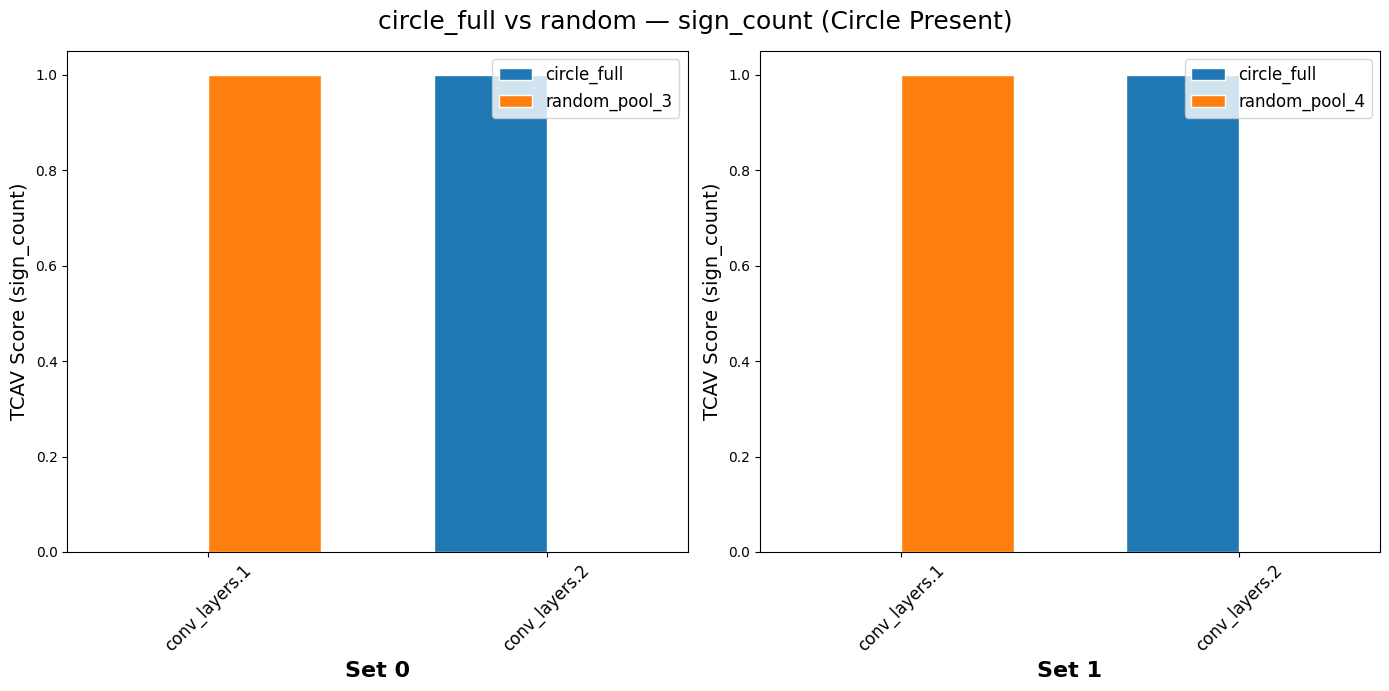

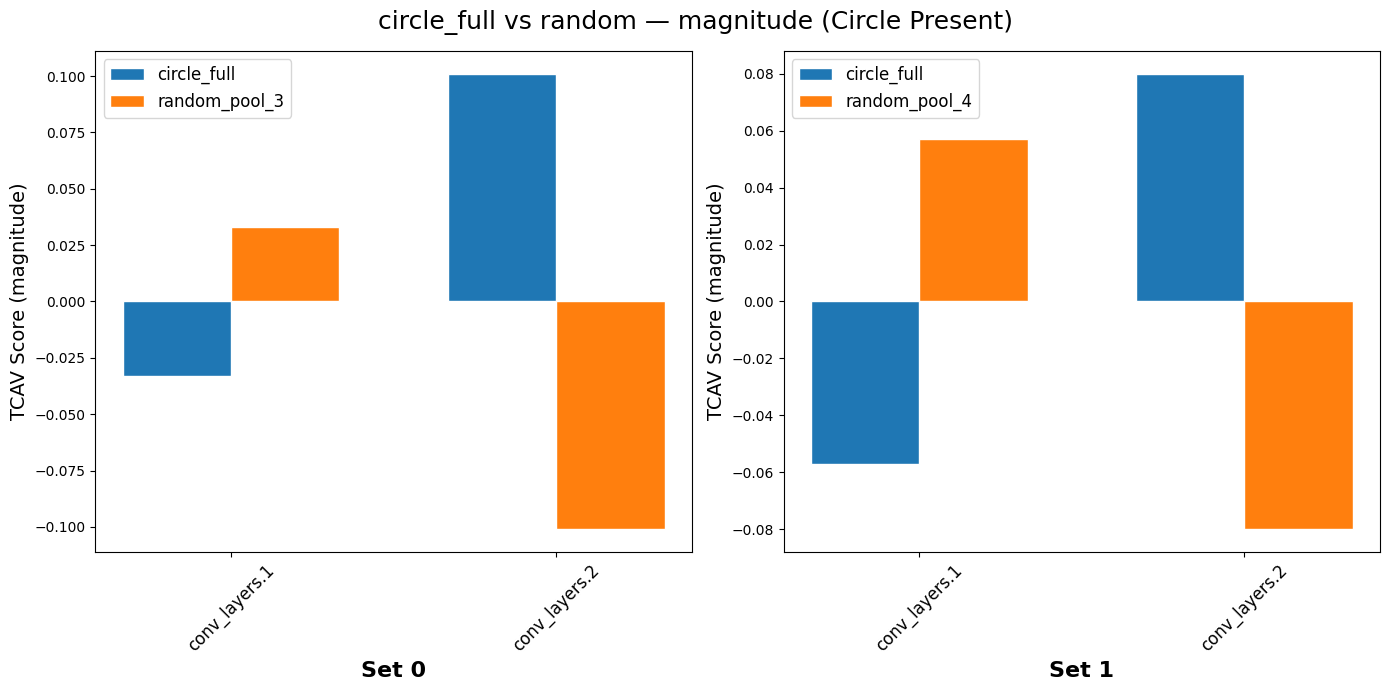


[2] Running TCAV: all concepts (Circle Present)...


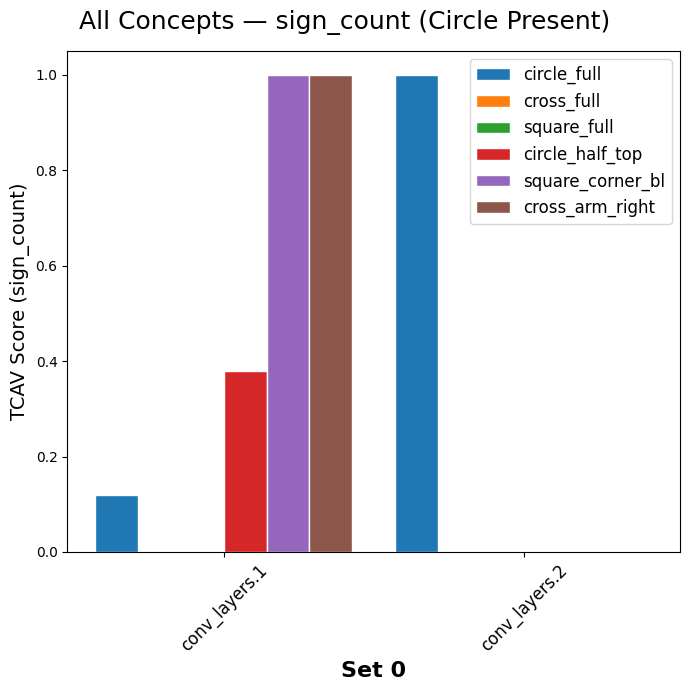

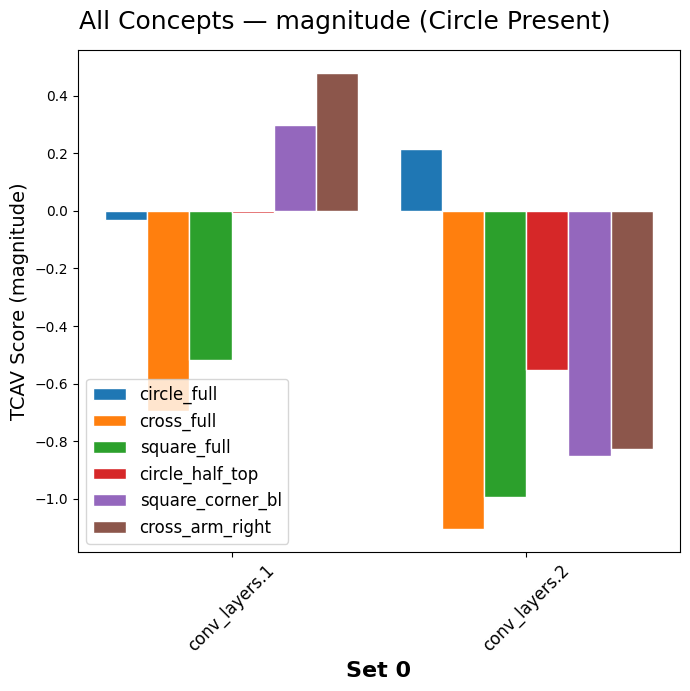


[3] Running TCAV: all concepts (Circle Absent)...


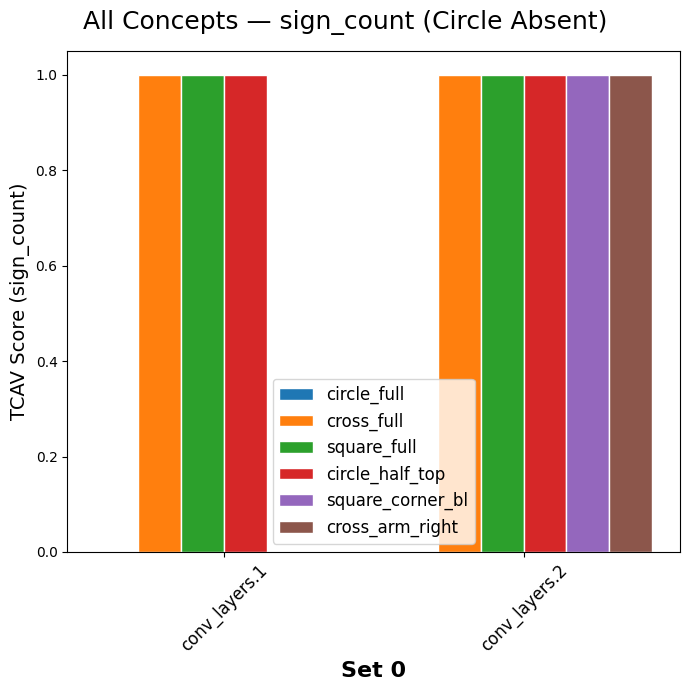

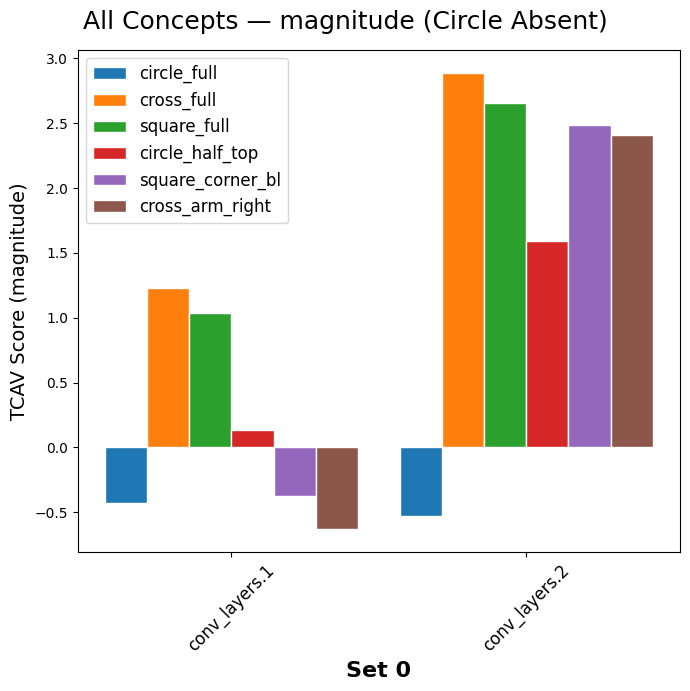

7388

In [6]:
##############################################
# Captum TCAV — Circle Detection Model
##############################################
#
# ┌─────────────────────────────────────────────────────────────────┐
# │ PRE-SIGMOID LOGIT APPROACH (faithful to Kim et al. 2018)       │
# │                                                                 │
# │ TCAV computes: S_C(x) = ∇_h f_k(x) · v_C                     │
# │ The directional derivative of the model output w.r.t. layer    │
# │ activations, dotted with the Concept Activation Vector.        │
# │                                                                 │
# │ Kim et al. use pre-softmax logits (not probabilities) so the   │
# │ gradient doesn't suffer from output saturation. We follow the  │
# │ same approach: the wrapper outputs pre-sigmoid logits as a     │
# │ 2-column tensor [-z, z], avoiding sigmoid saturation entirely. │
# │                                                                 │
# │ This means we use Captum's default LayerGradientXActivation    │
# │ (plain gradients), NOT LayerIntegratedGradients.               │
# │                                                                 │
# │ Additionally, Captum's DefaultClassifier has a device mismatch │
# │ bug on GPU (classes() returns CPU tensor, argmax returns CUDA).│
# │ We fix this with GPUClassifier below.                          │
# └─────────────────────────────────────────────────────────────────┘

import gc
import glob
import random
import numpy as np
import os
import copy
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
from torchvision import transforms
from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str
from captum.concept._utils.classifier import Classifier
from captum._utils.models.linear_model.model import SkLearnSGDClassifier

# ── GPU-safe classifier (fixes Captum's device mismatch bug) ─────────
# Captum's DefaultClassifier crashes on GPU because:
#   1. self.lm.classes() returns a CPU tensor
#   2. torch.argmax(predict, dim=1) returns a CUDA tensor
#   3. CPU tensor indexed by CUDA tensor → RuntimeError
# This classifier keeps everything on the same device.

class GPUClassifier(Classifier):
    def __init__(self):
        self.lm = SkLearnSGDClassifier(alpha=0.01, max_iter=1000, tol=1e-3)

    def train_and_eval(self, dataloader, test_split_ratio=0.33, **kwargs):
        inputs = []
        labels = []
        for inp, label in dataloader:
            inputs.append(inp)
            labels.append(label)

        all_inputs = torch.cat(inputs)
        all_labels = torch.cat(labels)
        device = all_inputs.device

        # Shuffle and split
        z_list = list(zip(all_inputs, all_labels))
        random.shuffle(z_list)
        test_size = int(test_split_ratio * len(z_list))
        z_test, z_train = z_list[:test_size], z_list[test_size:]
        x_test, y_test = zip(*z_test)
        x_train, y_train = zip(*z_train)
        x_train, x_test = torch.stack(x_train), torch.stack(x_test)
        y_train, y_test = torch.stack(y_train), torch.stack(y_test)

        self.lm.device = device
        self.lm.fit(DataLoader(TensorDataset(x_train, y_train)))

        predict = self.lm(x_test)
        # FIX: move classes() to the same device as argmax output
        classes = self.lm.classes().to(device)
        predict = classes[torch.argmax(predict, dim=1)]
        score = predict.long() == y_test.long()

        return {"accs": score.float().mean()}

    def weights(self):
        weights = self.lm.representation()
        if weights.shape[0] == 1:
            return torch.stack([-1 * weights[0], weights[0]])
        return weights

    def classes(self):
        return self.lm.classes().detach().numpy()

# ── 1. Setup ─────────────────────────────────────────────────────────

DEVICE = torch.device('cpu')
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
GLOBAL_TEST_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test')
CIRCLE_PRESENT_IDX = 1
CIRCLE_ABSENT_IDX = 0
print(f"TCAV device: {DEVICE}")

grayscale_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# ── 2. Pre-sigmoid logit wrapper ─────────────────────────────────────
# Captum TCAV expects [B, num_classes] output. Following Kim et al.,
# we output PRE-SIGMOID logits (not probabilities) to avoid sigmoid
# saturation killing gradients. Output: [-z, z] where z is the raw logit.

class LogitWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self._inner = model
        self.conv_layers = model.conv_layers
        self.fc_layers = model.fc_layers
        self.output = model.output

    def forward(self, x):
        x = x.to(next(self._inner.parameters()).device)
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        z = self.output(x)  # raw logit, NO sigmoid
        return torch.cat([-z, z], dim=1)

tcav_model = LogitWrapper(copy.deepcopy(nn_model).to(DEVICE))
tcav_model.eval()

# ── 3. Helpers ───────────────────────────────────────────────────────

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert('L')
    return grayscale_transform(img)

def assemble_concept(name, id, concepts_path=CONCEPTS_DIR):
    concept_path = os.path.join(concepts_path, name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=id, name=name, data_iter=concept_iter)

def load_test_images(class_dir):
    tensors = []
    for f in sorted(glob.glob(os.path.join(class_dir, '*.png'))):
        tensors.append(get_tensor_from_filename(f))
    return torch.stack(tensors)

def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores, layers, title, metric='sign_count'):
    n_sets = len(experimental_sets)
    fig, ax = plt.subplots(1, n_sets, figsize=(7 * n_sets, 7))
    if n_sets == 1:
        ax = [ax]

    for idx_es, concepts in enumerate(experimental_sets):
        concepts_key = concepts_to_str(concepts)
        n_concepts = len(concepts)
        barWidth = 1 / (n_concepts + 1)

        pos = [np.arange(len(layers))]
        for i in range(1, n_concepts):
            pos.append([(x + barWidth) for x in pos[i-1]])

        for i in range(n_concepts):
            val = [format_float(scores[metric][i])
                   for _, scores in tcav_scores[concepts_key].items()]
            ax[idx_es].bar(pos[i], val, width=barWidth, edgecolor='white',
                           label=concepts[i].name)

        ax[idx_es].set_xlabel(f'Set {idx_es}', fontweight='bold', fontsize=16)
        ax[idx_es].set_xticks([r + barWidth * (n_concepts - 1) / 2 for r in range(len(layers))])
        ax[idx_es].set_xticklabels(layers, fontsize=12, rotation=45)
        ax[idx_es].legend(fontsize=12)
        if metric == 'sign_count':
            ax[idx_es].set_ylim([0, 1.05])
        ax[idx_es].set_ylabel(f'TCAV Score ({metric})', fontsize=14)

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

# ── 4. Concepts ──────────────────────────────────────────────────────

circle_full   = assemble_concept("circle_full",      0)
cross_full    = assemble_concept("cross_full",        1)
square_full   = assemble_concept("square_full",       2)
circle_half   = assemble_concept("circle_half_top",   3)
square_corner = assemble_concept("square_corner_bl",  4)
cross_arm     = assemble_concept("cross_arm_right",   5)

random_0 = assemble_concept("random_0", 10)
random_1 = assemble_concept("random_1", 11)
random_2 = assemble_concept("random_pool_3", 12)
random_3 = assemble_concept("random_pool_4", 13)

# ── 5. Layers & TCAV instance ────────────────────────────────────────

layers = ['conv_layers.1', 'conv_layers.2']

mytcav = TCAV(
    model=tcav_model,
    layers=layers,
    model_id = "Circle_Medium"
    
)

# ── 6. Load test images ──────────────────────────────────────────────

circle_present_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'circle_present')).to(DEVICE)
circle_absent_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'circle_absent')).to(DEVICE)
print(f"Circle present: {circle_present_tensors.shape}")
print(f"Circle absent:  {circle_absent_tensors.shape}")

# ── 7. Experimental sets ─────────────────────────────────────────────

experimental_sets_rand = [
    [circle_full, random_2],
    [circle_full, random_3],
]

experimental_sets_all = [
    [circle_full, cross_full, square_full, circle_half, square_corner, cross_arm],
]

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: circle_full vs randoms
# ══════════════════════════════════════════════════════════════════════

print("\n[1] Running TCAV: circle_full vs randoms...")
scores_rand = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_rand,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — sign_count (Circle Present)')
plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — magnitude (Circle Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: All concepts head-to-head (Circle Present)
# ══════════════════════════════════════════════════════════════════════

print("\n[2] Running TCAV: all concepts (Circle Present)...")
scores_all_present = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — sign_count (Circle Present)')
plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — magnitude (Circle Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: All concepts head-to-head (Circle Absent)
# ══════════════════════════════════════════════════════════════════════

print("\n[3] Running TCAV: all concepts (Circle Absent)...")
scores_all_absent = mytcav.interpret(
    inputs=circle_absent_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_ABSENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — sign_count (Circle Absent)')
plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — magnitude (Circle Absent)',
                 metric='magnitude')

# Free experiments 1-3
del scores_rand, scores_all_present, scores_all_absent
gc.collect()

## Amb Cercles

In [7]:
local_explainer = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4', # Same distribution idk
    cav_method=METHOD_CAV,
    device=DEVICE,
)

local_explainer.setConcepts(CONCEPTS)
local_explainer.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

predictions = local_explainer.predict(no_sort=True)
predictions.info()

print(f'\nAvailable layers: {vtcav_model.getLayerNames()}')


Model: FlexNet_CircleMedium
    Image     Class name Confidence
00001.png Circle present       1.00

Available layers: ['conv_layers', 'conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0', 'fc_layers', 'fc_layers.0', 'fc_layers.0.0', 'fc_layers.1', 'fc_layers.1.0', 'output']


```
  FlexibleTNet                                                                                                                                               
  ├── conv_layers          → Sequential (the whole conv block container)                                                                                     
  │   └── 0                → Sequential (first conv block: Conv2d + ReLU + BN + MaxPool)                                                                     
  │       ├── 0            → Conv2d(1, 8, 3x3)        ← conv_layers.0.0                                                                                      
  │       ├── 1            → ReLU()
  │       ├── 2            → BatchNorm2d(8)
  │       └── 3            → MaxPool2d(2)
  ├── fc_layers            → Sequential (the whole FC block container)
  │   └── 0                → Sequential (first FC block: Linear + Dropout + ReLU)
  │       ├── 0            → Linear(32768 → 32)        ← fc_layers.0.0
  │       ├── 1            → Dropout(0.2)
  │       └── 2            → ReLU()
  ├── output               → Linear(32 → 1)
  └── final_act            → Sigmoid()
  ```
  

In [8]:
local_explainer.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer.concepts:
    for layer_name in local_explainer.layers:
        cl = local_explainer.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

Layers: 100%|██████████| 3/3 [00:19<00:00,  6.43s/it]

circle_full @ conv_layers.0: {0: 0.2077692598104477, 1: 0.05257507786154747}
circle_full @ conv_layers.1: {0: 0.4213610589504242, 1: 0.008559889160096645}
circle_full @ conv_layers.2: {0: 0.3524644374847412, 1: 0.0009032852831296623}
cross_full @ conv_layers.0: {0: 0.021870655938982964, 1: 0.003929656930267811}
cross_full @ conv_layers.1: {0: 0.2681702971458435, 1: 0.014067715033888817}
cross_full @ conv_layers.2: {0: 0.00011978435941273347, 1: 0.0035281036980450153}
square_full @ conv_layers.0: {0: 0.06694811582565308, 1: 0.05292201042175293}
square_full @ conv_layers.1: {0: 0.27463528513908386, 1: 0.013897798955440521}
square_full @ conv_layers.2: {0: 9.216183389071375e-05, 1: 0.002061194507405162}
circle_half_top @ conv_layers.0: {0: 0.024303019046783447, 1: 0.0050434209406375885}
circle_half_top @ conv_layers.1: {0: 0.28475576639175415, 1: 0.007574728690087795}
circle_half_top @ conv_layers.2: {0: 0.0028417236171662807, 1: 0.0032609286718070507}
square_corner_bl @ conv_layers.0: {0

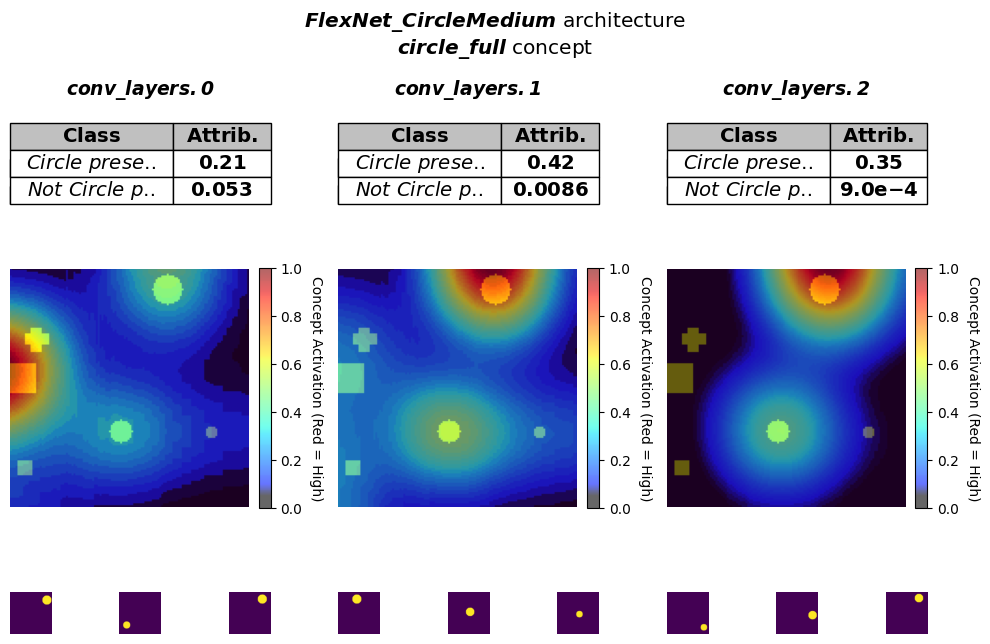

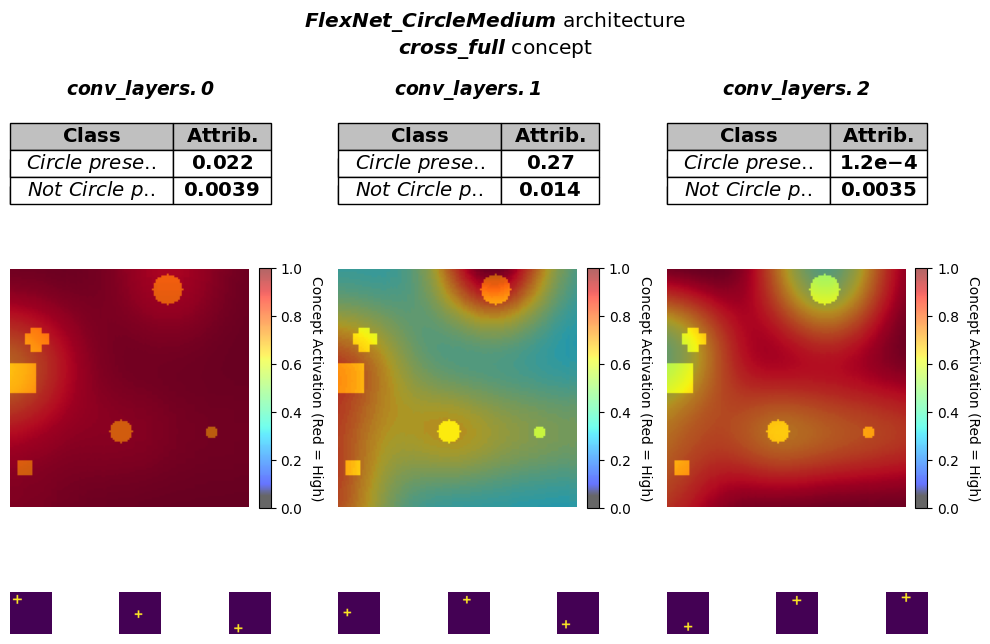

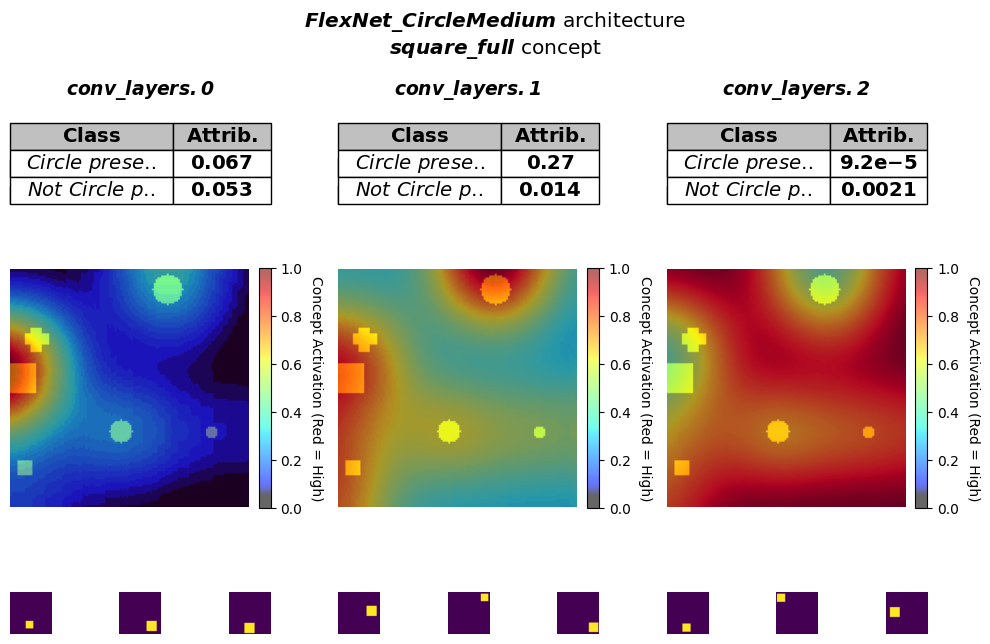

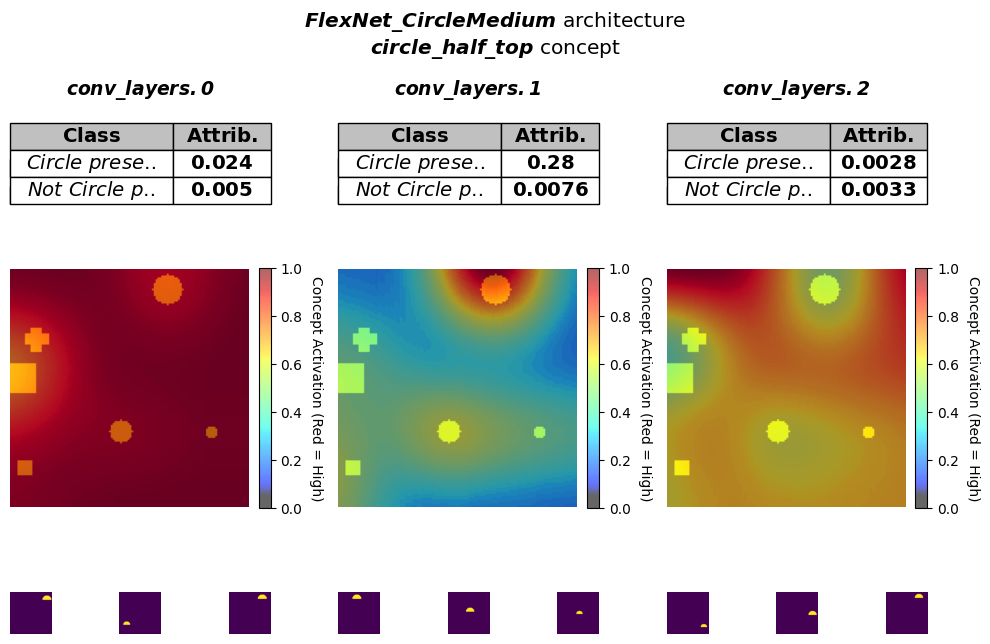

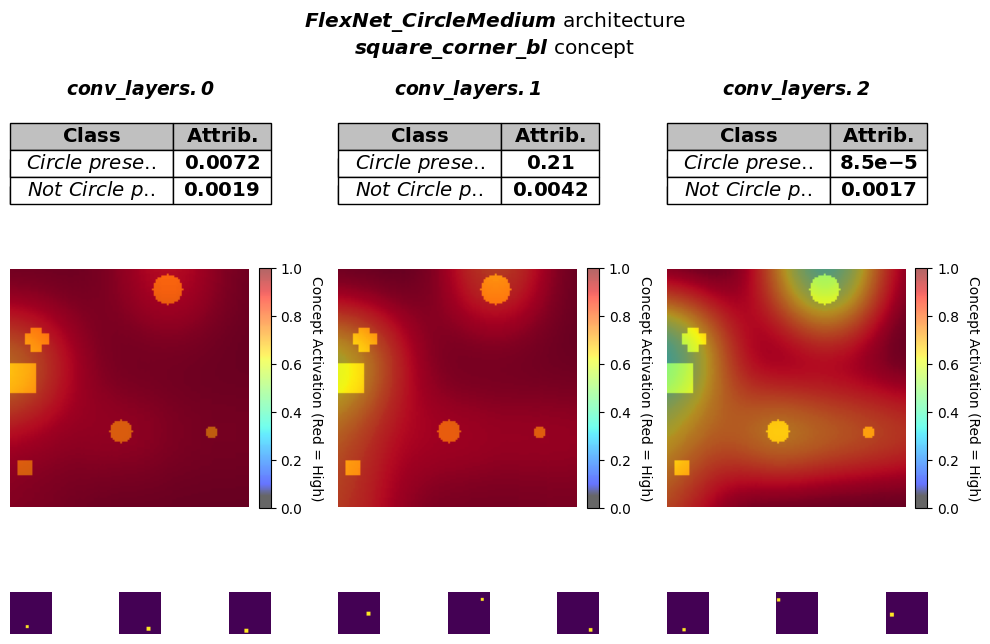

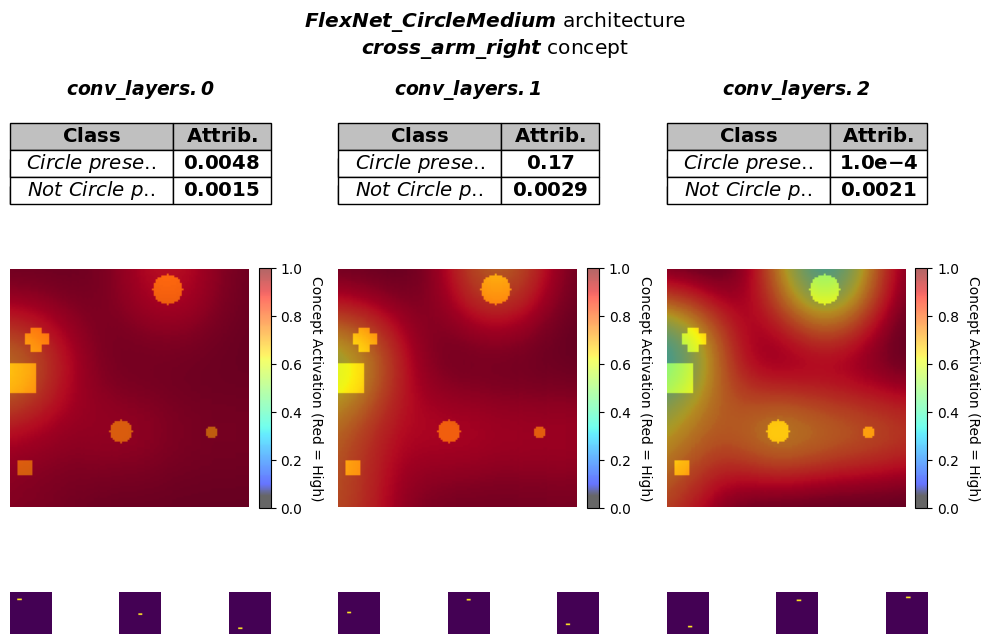

In [9]:
# Plot heatmaps
local_explainer.plot()

circle_full: norm=1.5716, emblem=(9.3900, 2.4595)
cross_full: norm=1.1937, emblem=(0.4284, 0.0000)
square_full: norm=1.7189, emblem=(4.4541, 2.6821)
circle_half_top: norm=1.2496, emblem=(0.4506, 0.0000)
square_corner_bl: norm=1.0876, emblem=(0.4435, 0.0000)
cross_arm_right: norm=1.0337, emblem=(0.4450, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8238
  circle_full vs square_full: 0.9667
  circle_full vs circle_half_top: 0.8756
  circle_full vs square_corner_bl: 0.6630
  circle_full vs cross_arm_right: 0.5924
  cross_full vs square_full: 0.7802
  cross_full vs circle_half_top: 0.9924
  cross_full vs square_corner_bl: 0.9621
  cross_full vs cross_arm_right: 0.9340
  square_full vs circle_half_top: 0.8316
  square_full vs square_corner_bl: 0.6234
  square_full vs cross_arm_right: 0.5526
  circle_half_top vs square_corner_bl: 0.9397
  circle_half_top vs cross_arm_right: 0.9050
  square_corner_bl vs cross_arm_right: 0.9954


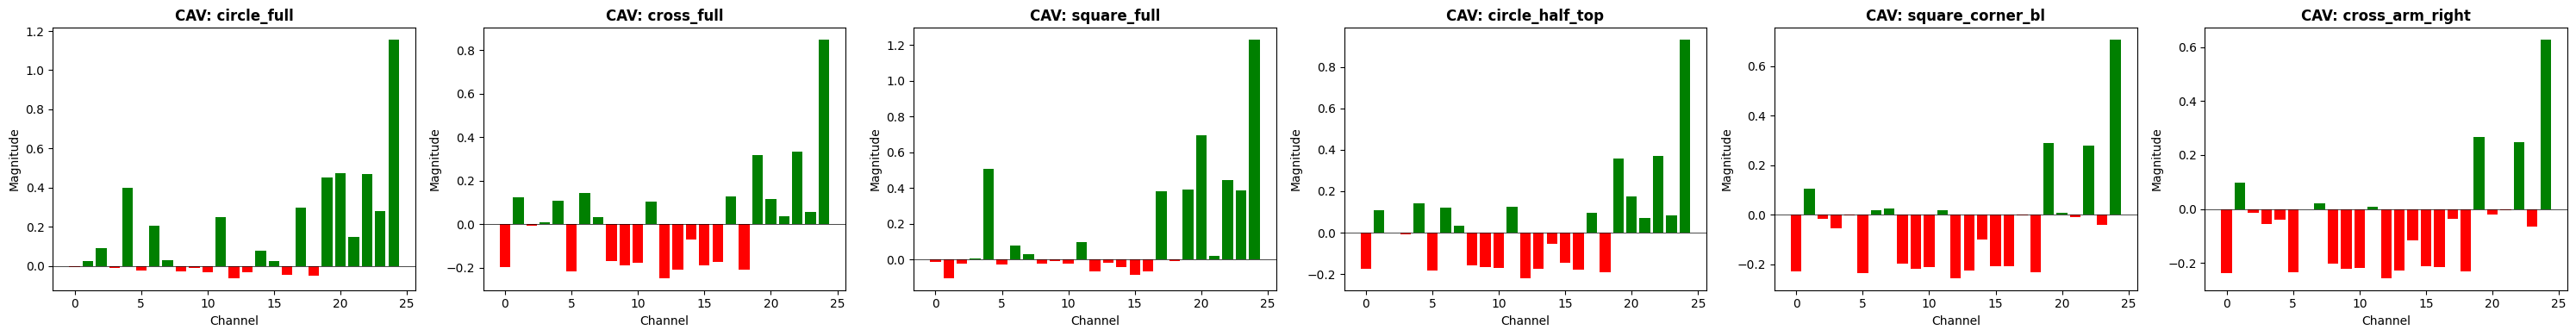

circle_full: norm=0.7404, emblem=(16.0340, 0.0000)
cross_full: norm=0.6946, emblem=(1.4951, 0.0000)
square_full: norm=0.7727, emblem=(1.3772, 0.0000)
circle_half_top: norm=0.6990, emblem=(2.9933, 0.0000)
square_corner_bl: norm=0.6329, emblem=(0.3124, 0.0000)
cross_arm_right: norm=0.6493, emblem=(0.3575, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8259
  circle_full vs square_full: 0.7917
  circle_full vs circle_half_top: 0.8974
  circle_full vs square_corner_bl: 0.6497
  circle_full vs cross_arm_right: 0.5239
  cross_full vs square_full: 0.9801
  cross_full vs circle_half_top: 0.9550
  cross_full vs square_corner_bl: 0.8691
  cross_full vs cross_arm_right: 0.7593
  square_full vs circle_half_top: 0.9277
  square_full vs square_corner_bl: 0.8380
  square_full vs cross_arm_right: 0.7082
  circle_half_top vs square_corner_bl: 0.8771
  circle_half_top vs cross_arm_right: 0.7671
  square_corner_bl vs cross_arm_right: 0.9632


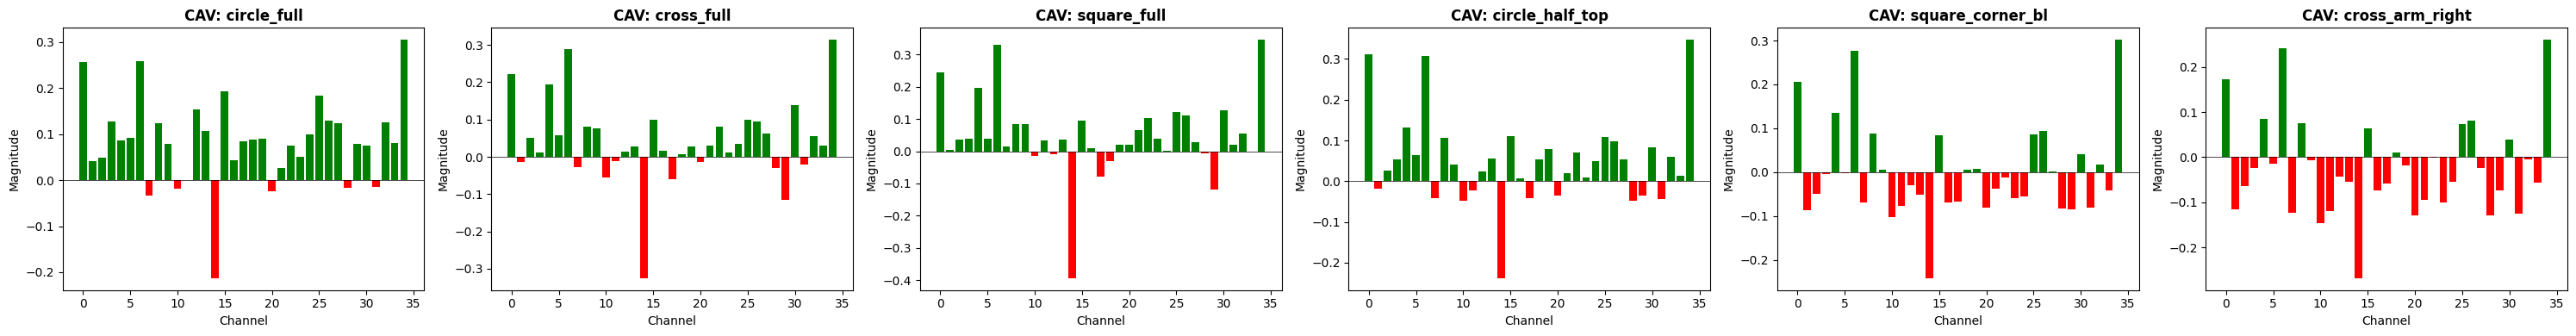

circle_full: norm=0.9158, emblem=(22.0275, 0.0002)
cross_full: norm=0.9121, emblem=(0.6688, 0.0000)
square_full: norm=0.9478, emblem=(0.6941, 0.0000)
circle_half_top: norm=0.8610, emblem=(0.3560, 0.0000)
square_corner_bl: norm=0.8550, emblem=(0.6206, 0.0000)
cross_arm_right: norm=0.8437, emblem=(0.6171, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: -0.0016
  circle_full vs square_full: -0.0301
  circle_full vs circle_half_top: 0.5617
  circle_full vs square_corner_bl: -0.0072
  circle_full vs cross_arm_right: -0.0162
  cross_full vs square_full: 0.9935
  cross_full vs circle_half_top: 0.7349
  cross_full vs square_corner_bl: 0.9879
  cross_full vs cross_arm_right: 0.9881
  square_full vs circle_half_top: 0.7242
  square_full vs square_corner_bl: 0.9950
  square_full vs cross_arm_right: 0.9938
  circle_half_top vs square_corner_bl: 0.7411
  circle_half_top vs cross_arm_right: 0.7334
  square_corner_bl vs cross_arm_right: 0.9993


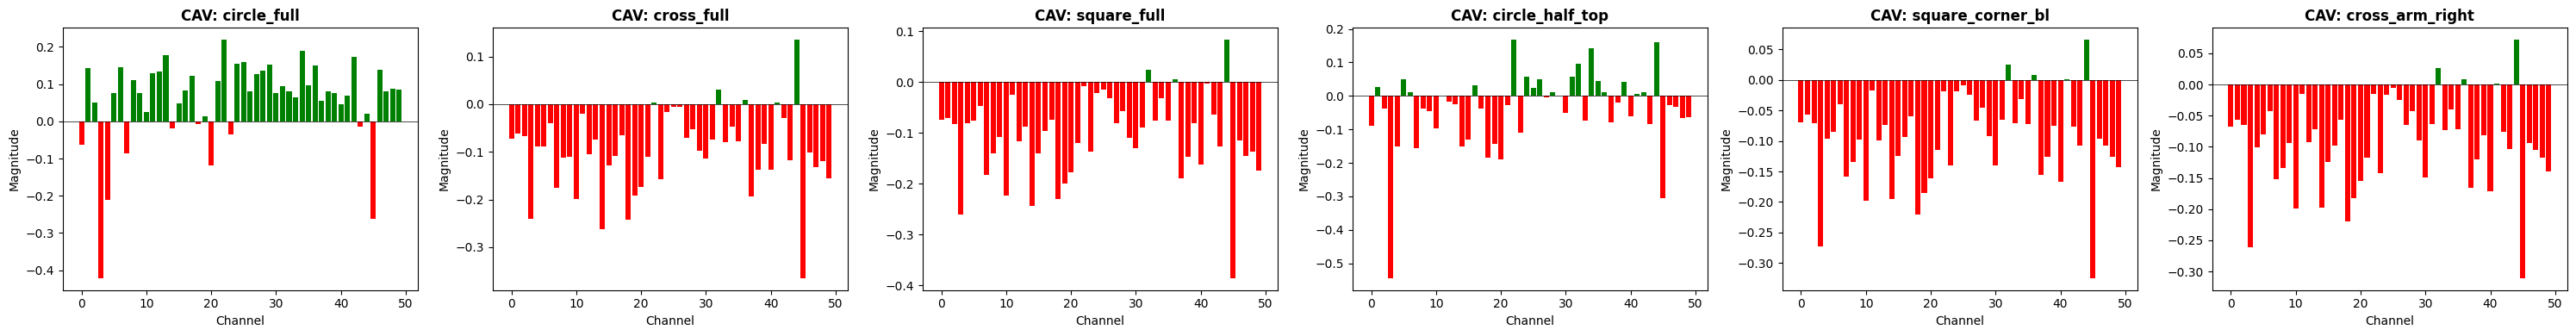

In [10]:
for x in [0, 1, 2]:
    concept_names = local_explainer.concepts
    layer_name = local_explainer.layers[x]

    
    cavs = {}
    for cn in concept_names:
        cav = local_explainer.getCAVs(layer_name, cn)
        cavs[cn] = cav.direction
        print(f'{cn}: norm={cav.direction.norm():.4f}, '
            f'emblem=({cav.concept_emblem[0]:.4f}, {cav.concept_emblem[1]:.4f})')

    
    print('\nCosine similarities between CAV directions:')
    for a, b in combinations(concept_names, 2):
        cos = F.cosine_similarity(
            cavs[a].unsqueeze(0), cavs[b].unsqueeze(0)
        ).item()
        print(f'  {a} vs {b}: {cos:.4f}')

    
    fig, axes = plt.subplots(1, len(concept_names), figsize=(5 * len(concept_names), 4))
    for ax, name in zip(axes, concept_names):
        d = cavs[name].cpu().numpy()
        ax.bar(range(len(d)), d, color=['green' if v > 0 else 'red' for v in d])
        ax.set_title(f'CAV: {name}', fontweight='bold')
        ax.set_xlabel('Channel')
        ax.set_ylabel('Magnitude')
        ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Sense Cercles


Model: FlexNet_CircleMedium
    Image     Class name Confidence
00120.png Circle present       0.00


Layers: 100%|██████████| 3/3 [00:18<00:00,  6.31s/it]


circle_full @ conv_layers.0: {0: 0.22180305421352386, 1: 0.07329066097736359}
circle_full @ conv_layers.1: {0: 0.12079572677612305, 1: 0.049985580146312714}
circle_full @ conv_layers.2: {0: 0.0025312192738056183, 1: 0.0032227723859250546}
cross_full @ conv_layers.0: {0: 0.03202607482671738, 1: 0.00838159117847681}
cross_full @ conv_layers.1: {0: 0.15804320573806763, 1: 0.21350647509098053}
cross_full @ conv_layers.2: {0: 0.009653303772211075, 1: 0.1661577820777893}
square_full @ conv_layers.0: {0: 0.12873339653015137, 1: 0.08741286396980286}
square_full @ conv_layers.1: {0: 0.13923342525959015, 1: 0.21010592579841614}
square_full @ conv_layers.2: {0: 0.0073075322434306145, 1: 0.08574090898036957}
circle_half_top @ conv_layers.0: {0: 0.03352738544344902, 1: 0.00897216796875}
circle_half_top @ conv_layers.1: {0: 0.11359065771102905, 1: 0.058212459087371826}
circle_half_top @ conv_layers.2: {0: 0.00526775699108839, 1: 0.13038678467273712}
square_corner_bl @ conv_layers.0: {0: 0.0068143424

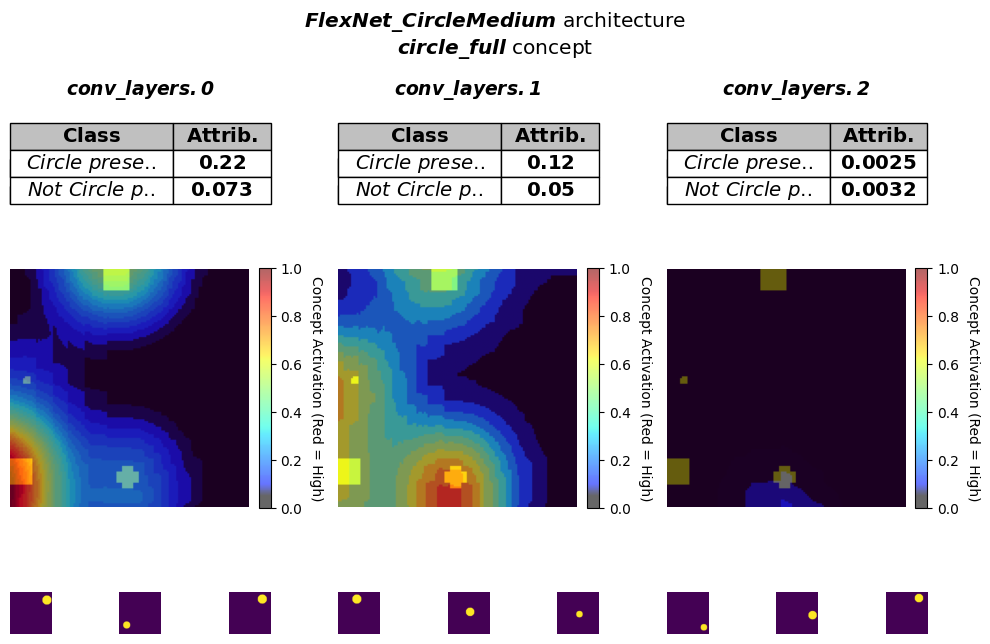

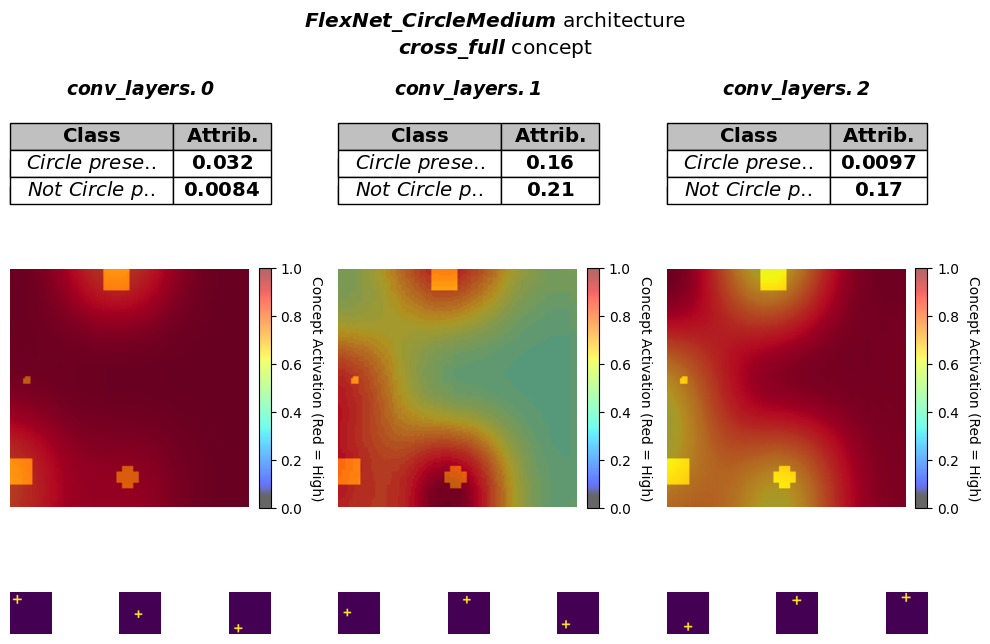

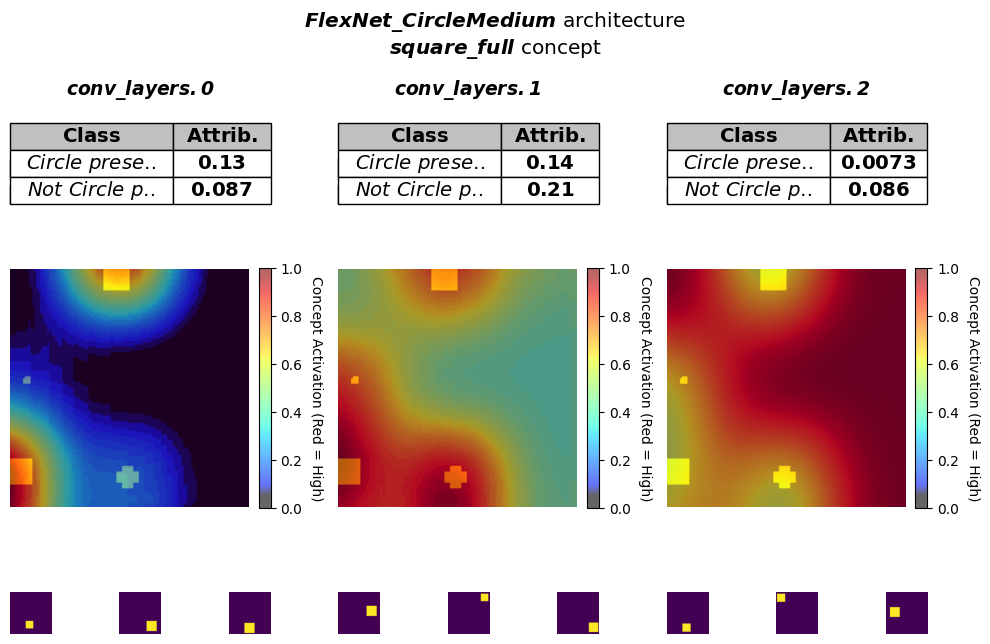

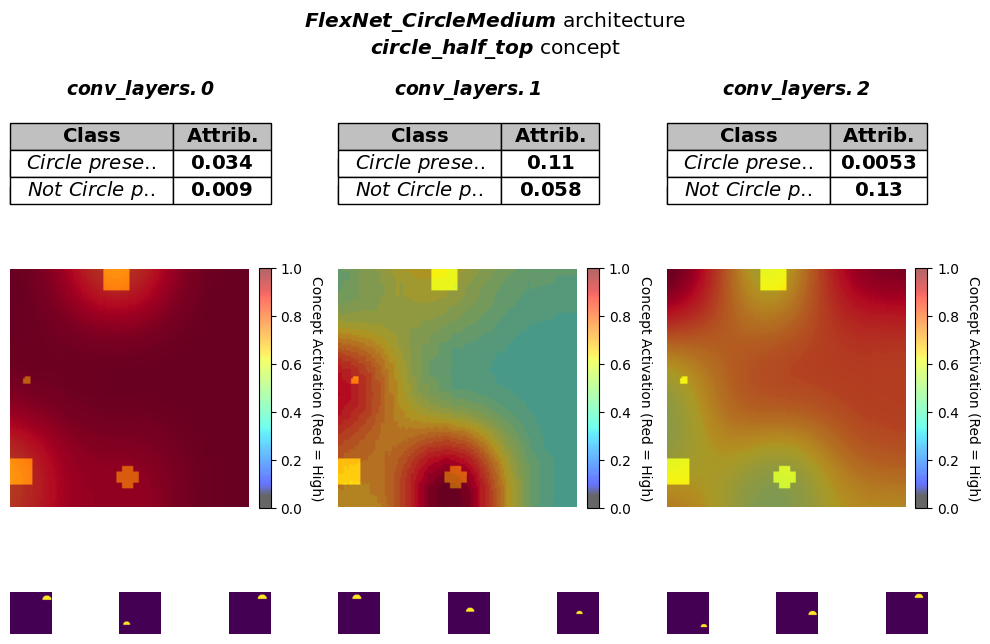

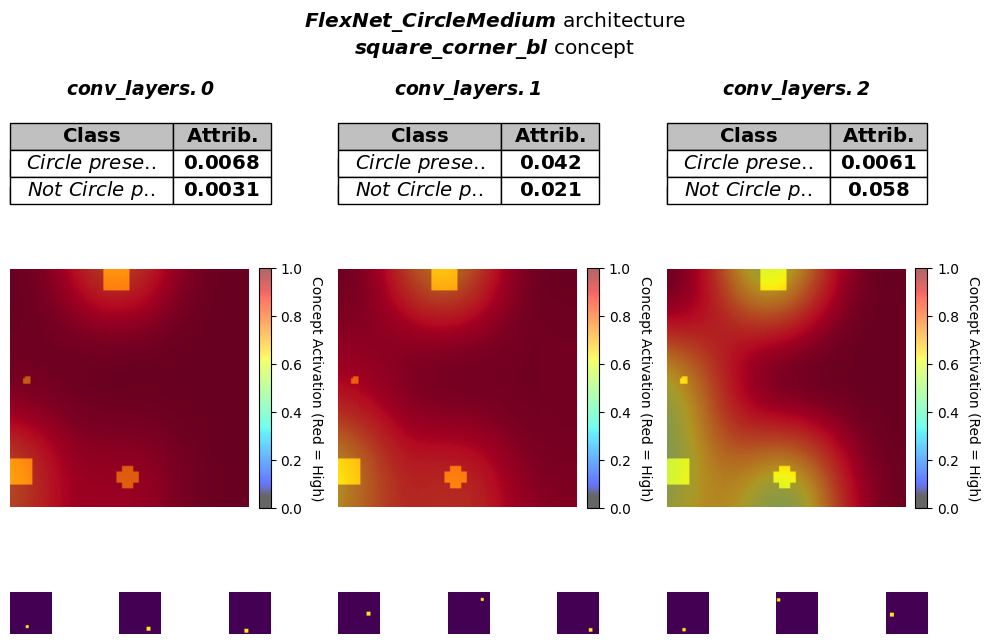

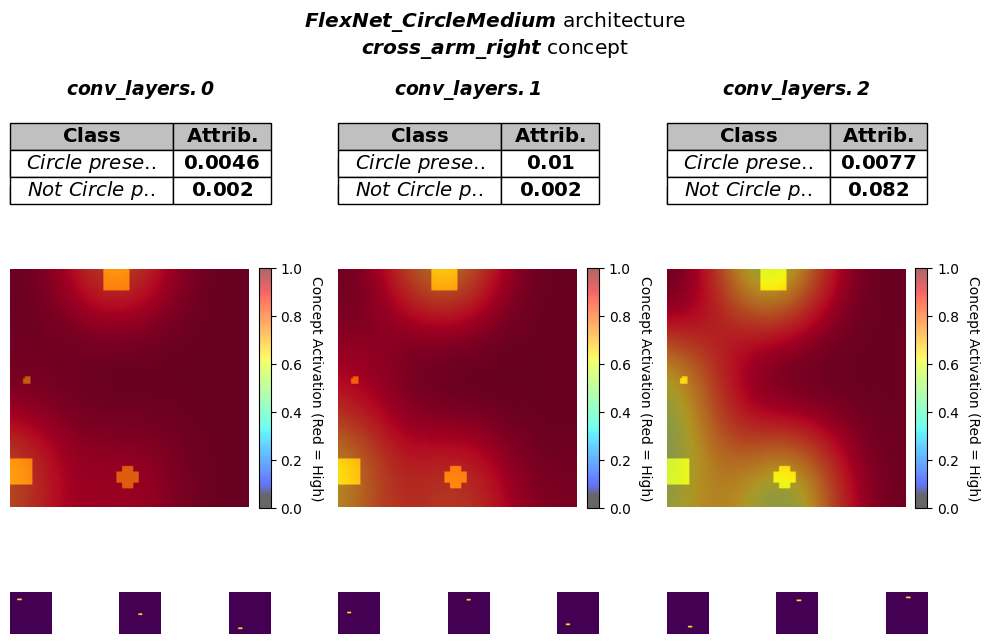

In [11]:
local_explainer2 = LocalVisualTCAV(
    test_image_filename=f'{img_without[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_explainer2.setConcepts(CONCEPTS)
local_explainer2.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

predictions2 = local_explainer2.predict(no_sort=True)
predictions2.info()

local_explainer2.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer2.concepts:
    for layer_name in local_explainer2.layers:
        cl = local_explainer2.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

local_explainer2.plot()

## Global Explanation

In [12]:
import shutil

# Select 200 images per grup as stated in the paper
circle_indices, no_circle_indices = [], []
for r in rows:
    idx, c = int(r['']), int(r['c'])
    if c > 0 and len(circle_indices) < 200:
        circle_indices.append(idx)
    elif c == 0 and len(no_circle_indices) < 200:
        no_circle_indices.append(idx)


global_test_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test'
for group_name, indices in [('circle_present', circle_indices), ('circle_absent', no_circle_indices)]:
    group_dir = global_test_dir / group_name
    group_dir.mkdir(parents=True, exist_ok=True)
    for idx in indices:
        src = val_dir / f'{idx:05d}.png'
        dst = group_dir / f'{idx:05d}.png'
        if not dst.exists():
            shutil.copy2(src, dst)

print(f'Circle present: {len(circle_indices)} images')
print(f'Circle absent:  {len(no_circle_indices)} images')
print(f'Test dir: {global_test_dir}')

Circle present: 200 images
Circle absent:  200 images
Test dir: /home/dlc/VisualTCAV/data/aixi_shape/val_global_test


In [13]:
global_circle = GlobalVisualTCAV(
    target_class='Circle present',
    test_images_folder='circle_present',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_circle.setConcepts(CONCEPTS)
global_circle.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

print('Running global explanation - Circle Present...')
global_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Present...


Layers: 100%|██████████| 3/3 [02:27<00:00, 49.10s/it]


In [14]:
global_circle.statsInfo()


Model: FlexNet_CircleMedium | Class: Circle present | Folder: circle_present
         Concept         Layer        Attrib. mean    Attrib. 95.45% CI
     circle_full conv_layers.0       0.216 ± 0.038       [0.211, 0.222]
                 conv_layers.1      0.414 ± 0.0328       [0.409, 0.418]
                 conv_layers.2      0.342 ± 0.0302       [0.338, 0.347]
      cross_full conv_layers.0    0.0244 ± 0.00385      [0.0239, 0.025]
                 conv_layers.1      0.263 ± 0.0423       [0.257, 0.269]
                 conv_layers.2 0.000224 ± 0.000288 [0.000183, 0.000264]
     square_full conv_layers.0    0.0745 ± 0.00895     [0.0732, 0.0758]
                 conv_layers.1      0.261 ± 0.0478       [0.254, 0.267]
                 conv_layers.2 0.000135 ± 0.000178   [0.00011, 0.00016]
 circle_half_top conv_layers.0    0.0279 ± 0.00402     [0.0273, 0.0284]
                 conv_layers.1       0.292 ± 0.033       [0.287, 0.297]
                 conv_layers.2     0.00242 ± 0.003     [0.

In [15]:
global_no_circle = GlobalVisualTCAV(
    target_class='Circle absent',  
    test_images_folder='circle_absent',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_no_circle.setConcepts(CONCEPTS)
global_no_circle.setLayers(['conv_layers.0', 'conv_layers.1','conv_layers.2'])

print('Running global explanation - Circle Absent...')
global_no_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Circle Absent...


Layers: 100%|██████████| 3/3 [02:30<00:00, 50.02s/it]


In [16]:
global_no_circle.statsInfo()


Model: FlexNet_CircleMedium | Class: Circle absent | Folder: circle_absent
         Concept         Layer      Attrib. mean  Attrib. 95.45% CI
     circle_full conv_layers.0      0.2 ± 0.0913     [0.187, 0.213]
                 conv_layers.1     0.121 ± 0.078      [0.11, 0.132]
                 conv_layers.2  0.00784 ± 0.0141 [0.00585, 0.00983]
      cross_full conv_layers.0   0.0217 ± 0.0178   [0.0192, 0.0243]
                 conv_layers.1    0.115 ± 0.0629     [0.106, 0.124]
                 conv_layers.2   0.0084 ± 0.0103 [0.00694, 0.00985]
     square_full conv_layers.0    0.107 ± 0.0455     [0.101, 0.113]
                 conv_layers.1     0.107 ± 0.057    [0.0987, 0.115]
                 conv_layers.2 0.00479 ± 0.00581 [0.00397, 0.00561]
 circle_half_top conv_layers.0   0.0253 ± 0.0196    [0.0225, 0.028]
                 conv_layers.1   0.0933 ± 0.0647    [0.0842, 0.102]
                 conv_layers.2  0.0048 ± 0.00683 [0.00384, 0.00577]
square_corner_bl conv_layers.0 0.00911 ±

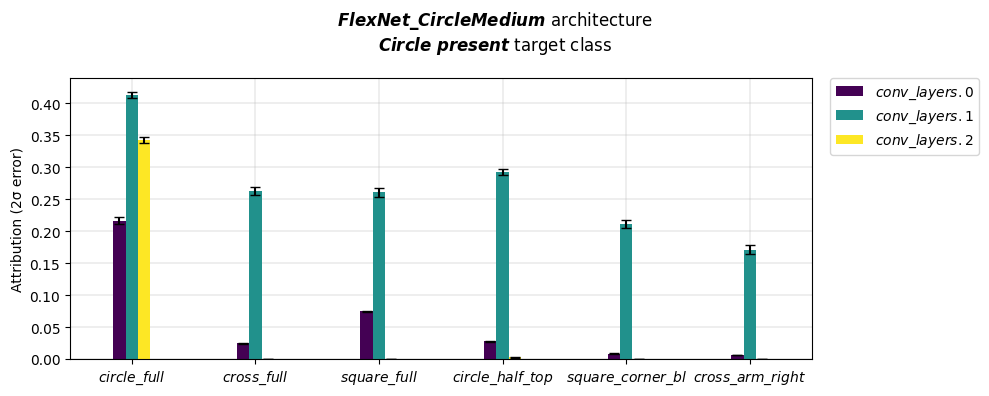

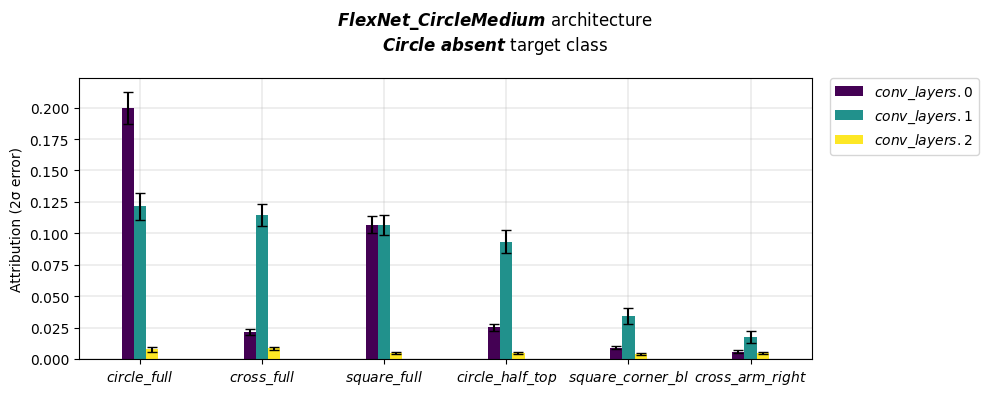

In [17]:
global_circle.plot()
global_no_circle.plot()

In [18]:
# --- Retrieve all conv layer names from the model ---
all_conv_layers = [name for name in vtcav_model.getLayerNames() if name.startswith('conv_layers.')]
print(f'Conv layers found: {all_conv_layers}\n')

local_clf = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_clf.setConcepts(CONCEPTS)
local_clf.setLayers(all_conv_layers)

predictions_clf = local_clf.predict(no_sort=True)
local_clf.explain(cache_cav=False, cache_random=False)

# --- Print classifier-based CAVs per layer ---
print('=== Classifier-based CAVs ===')
for layer_name in all_conv_layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_clf.concepts:
        cav = local_clf.getCAVs(layer_name, concept_name)
        attribs = local_clf.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: accuracy={cav.accuracy:.3f}, attribs={attribs}')

# --- Print centroid-based CAVs per layer (from earlier explainer) ---
print('\n=== Centroid-based CAVs (from section 6) ===')
for layer_name in local_explainer.layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_explainer.concepts:
        attribs = local_explainer.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: attribs={attribs}')

Conv layers found: ['conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0']



Layers: 100%|██████████| 6/6 [00:37<00:00,  6.22s/it]

=== Classifier-based CAVs ===

--- conv_layers.0 ---
  circle_full: accuracy=1.000, attribs={0: 0.20763102173805237, 1: 0.05219339206814766}
  cross_full: accuracy=1.000, attribs={0: 0.02191539853811264, 1: 0.0039001568220555782}
  square_full: accuracy=1.000, attribs={0: 0.06699769198894501, 1: 0.05248431861400604}
  circle_half_top: accuracy=1.000, attribs={0: 0.024298714473843575, 1: 0.0050049289129674435}
  square_corner_bl: accuracy=1.000, attribs={0: 0.0072064269334077835, 1: 0.0019198099616914988}
  cross_arm_right: accuracy=1.000, attribs={0: 0.004786377772688866, 1: 0.0014703217893838882}

--- conv_layers.0.0 ---
  circle_full: accuracy=0.970, attribs={0: 0.002170841908082366, 1: 0.002048318739980459}
  cross_full: accuracy=0.980, attribs={0: 0.0023781880736351013, 1: 0.0022330028004944324}
  square_full: accuracy=0.970, attribs={0: 0.0021882369183003902, 1: 0.00207475945353508}
  circle_half_top: accuracy=0.980, attribs={0: 0.0023761731572449207, 1: 0.0022323739249259233}
  s

In [19]:
# --- Compare centroid vs classifier CAV directions across all shared layers ---
shared_layers = [l for l in all_conv_layers if l in local_explainer.layers]

print('Cosine similarity between centroid and classifier CAV directions:')
for layer_name in shared_layers:
    print(f'\n--- {layer_name} ---')
    for cn in concept_names:
        d_centroid = local_explainer.getCAVs(layer_name, cn).direction   # shape: [C]
        d_classifier = local_clf.getCAVs(layer_name, cn).direction       # shape: [C]
        cos = F.cosine_similarity(
            d_centroid.unsqueeze(0),   # [1, C]
            d_classifier.unsqueeze(0)  # [1, C]
        ).item()
        print(f'  {cn}: {cos:.4f}')

Cosine similarity between centroid and classifier CAV directions:

--- conv_layers.0 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.1 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.2 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000


In [20]:
######################################################################
# Spatial Localization Evaluation — Circle_Large.ipynb
#
# Adapted for the new data/ layout:
#   data/val/*.png        — validation images (128×128 grayscale)
#   data/val/gt/*.png     — GT RGB masks (R=crosses, G=squares, B=circles)
#   data/val/dades.csv    — metadata (columns: '', c, s, cr)
#
# The Circle_Large model is a binary CNN that detects circle presence.
# We validate that the "circle_full" concept map spatially aligns with
# the blue channel (circles) of the GT masks.
#
# Metrics:
#   - Soft IoU:      continuous Jaccard (higher = better)
#   - Balanced MSE:  error balanced inside/outside GT (lower = better)
#   - EMD:           Earth Mover's Distance (lower = better)
#   - MIN:           histogram intersection (higher = better)
#   - Neg. Act.:     mean activation on images WITHOUT circles (lower = better)
#
# Paste this cell after the existing Circle_Large.ipynb setup
# (after cell ~10 where local_explainer.explain() has been called).
# Requires: spatial_evaluation_circles.py in the project directory.
######################################################################

import csv
import numpy as np
from pathlib import Path
from spatial_evaluation_circles import (
    evaluate_spatial_localization,
    evaluate_all_layers,
    print_spatial_summary,
    load_image_indices_from_csv,
)

# ============================================================
# CONFIG — paths relative to PROJECT_ROOT (defined in notebook)
# ============================================================

# New data layout: GT masks live inside data/val/gt/
GT_DIR = str(PROJECT_ROOT / 'data_gt'/ 'data' / 'val' / 'gt')
IMAGES_DIR = str(PROJECT_ROOT / 'data_gt'/ 'data' / 'val')
VAL_CSV = str(PROJECT_ROOT / 'data_gt'/ 'data' / 'val' / 'dades.csv')

# Layers to evaluate (from the notebook — adjust if your model has more/fewer)
LAYERS_TO_EVAL = ['conv_layers.0', 'conv_layers.1', 'conv_layers.2']

# How many images to evaluate per category
N_EVAL_IMAGES = 200

# ============================================================
# STEP 1: Select positive/negative image indices from CSV
#         column 'c' = circle count (0 = absent, 1+ = present)
# ============================================================

circle_present_indices, circle_absent_indices = load_image_indices_from_csv(
    csv_path=VAL_CSV,
    shape_type="circle",
    n_positive=N_EVAL_IMAGES,
    n_negative=N_EVAL_IMAGES,
)

print(f"Positive images (with circles):    {len(circle_present_indices)}")
print(f"Negative images (without circles): {len(circle_absent_indices)}")

# ============================================================
# STEP 2: Set up a LocalVisualTCAV for evaluation
#         Reuses vtcav_model from the notebook
# ============================================================

eval_explainer = LocalVisualTCAV(
    test_image_filename=f'{circle_present_indices[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

eval_explainer.setConcepts(CONCEPTS)
eval_explainer.setLayers(LAYERS_TO_EVAL)

_ = eval_explainer.predict(no_sort=True)
eval_explainer.explain(cache_cav=True, cache_random=True)

# ============================================================
# STEP 3: Evaluate "circle_full" concept vs GT circle positions
#         across all conv layers
# ============================================================

print("\n" + "=" * 60)
print("Evaluating: circle_full concept vs GT circle positions")
print("(GT = blue channel of data/val/gt/*.png)")
print("=" * 60)

circle_summaries = evaluate_all_layers(
    vtcav_instance=eval_explainer,
    gt_dir=GT_DIR,
    image_indices=circle_present_indices,
    concept_name="circle_full",
    layer_names=LAYERS_TO_EVAL,
    images_dir=IMAGES_DIR,
    shape_type="circle",
    negative_indices=circle_absent_indices,
    device=DEVICE,
)

print_spatial_summary(circle_summaries)

# ============================================================
# STEP 4: Negative controls — cross and square concept maps
#         should NOT align with circle GT positions
# ============================================================

print("\n" + "=" * 60)
print("Negative control: cross_full concept vs GT circle positions")
print("(should show LOW IoU — crosses shouldn't align with circles)")
print("=" * 60)

cross_summary = evaluate_spatial_localization(
    vtcav_instance=eval_explainer,
    gt_dir=GT_DIR,
    image_indices=circle_present_indices,
    concept_name="cross_full",
    layer_name=LAYERS_TO_EVAL[-1],
    images_dir=IMAGES_DIR,
    shape_type="circle",           # compare cross concept map against CIRCLE GT
    device=DEVICE,
)

print(f"\n  cross_full @ {LAYERS_TO_EVAL[-1]}:")
print(f"    Soft IoU:     {cross_summary.mean_soft_iou:.4f} ± {cross_summary.std_soft_iou:.4f}")
print(f"    Balanced MSE: {cross_summary.mean_balanced_mse:.4f} ± {cross_summary.std_balanced_mse:.4f}")

print("\n" + "=" * 60)
print("Negative control: square_full concept vs GT circle positions")
print("=" * 60)

square_summary = evaluate_spatial_localization(
    vtcav_instance=eval_explainer,
    gt_dir=GT_DIR,
    image_indices=circle_present_indices,
    concept_name="square_full",
    layer_name=LAYERS_TO_EVAL[-1],
    images_dir=IMAGES_DIR,
    shape_type="circle",           # compare square concept map against CIRCLE GT
    device=DEVICE,
)

print(f"\n  square_full @ {LAYERS_TO_EVAL[-1]}:")
print(f"    Soft IoU:     {square_summary.mean_soft_iou:.4f} ± {square_summary.std_soft_iou:.4f}")
print(f"    Balanced MSE: {square_summary.mean_balanced_mse:.4f} ± {square_summary.std_balanced_mse:.4f}")

# ============================================================
# STEP 5: Summary comparison at last layer
# ============================================================

print("\n" + "=" * 60)
print("COMPARISON at last layer: concept map vs CIRCLE ground truth")
print("=" * 60)
print(f"\n{'Concept':<20} {'Soft IoU ↑':>14} {'Bal.MSE ↓':>14}")
print("-" * 50)

last_circle = circle_summaries[-1]
print(f"{'circle_full':<20} {last_circle.mean_soft_iou:>14.4f} {last_circle.mean_balanced_mse:>14.4f}")
print(f"{'cross_full':<20} {cross_summary.mean_soft_iou:>14.4f} {cross_summary.mean_balanced_mse:>14.4f}")
print(f"{'square_full':<20} {square_summary.mean_soft_iou:>14.4f} {square_summary.mean_balanced_mse:>14.4f}")

print("\n→ circle_full should have the HIGHEST IoU and LOWEST MSE.")
print("  cross_full and square_full serve as negative controls.")


Positive images (with circles):    200
Negative images (without circles): 200


Layers: 100%|██████████| 3/3 [00:01<00:00,  1.55it/s]



Evaluating: circle_full concept vs GT circle positions
(GT = blue channel of data/val/gt/*.png)
  Evaluating circle_full @ conv_layers.0...
  Evaluating circle_full @ conv_layers.1...
  Evaluating circle_full @ conv_layers.2...

Concept              Layer                   N     Soft IoU ↑      Bal.MSE ↓          EMD ↓          MIN ↑  Neg.Act ↓
------------------------------------------------------------------------------------------------------------------
circle_full          conv_layers.0         200  0.0161±0.0247  0.4834±0.0283  0.0003±0.0001  0.0329±0.0478     0.0116
circle_full          conv_layers.1         200  0.0081±0.0203  0.4850±0.0374  0.0014±0.0005  0.0291±0.0636     0.0079
circle_full          conv_layers.2         200  0.0156±0.0456  0.4720±0.0828  0.0058±0.0025  0.0494±0.1180     0.0027

Negative control: cross_full concept vs GT circle positions
(should show LOW IoU — crosses shouldn't align with circles)

  cross_full @ conv_layers.2:
    Soft IoU:     0.0000 ± 0.0

In [22]:

# ══════════════════════════════════════════════════════════════
# Spatial Localization Evaluation — evaluation_metrics.py
# ══════════════════════════════════════════════════════════════
# CONFIG: set these two to choose what to evaluate
CONCEPT_NAME   = "circle_full"   # concept whose map to evaluate
SHAPE_TYPE     = "circle"        # "cross" | "square" | "circle"  (GT channel)

LAYERS_TO_EVAL = ['conv_layers.0', 'conv_layers.1', 'conv_layers.2']
N_EVAL         = 300             # max positive / negative images
# ══════════════════════════════════════════════════════════════

import sys, os, csv, importlib
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from collections import defaultdict
from captum.attr import LayerActivation

# Ensure VisualTCAV root (parent of notebooks_circles/) is on the path
_here = Path(os.path.abspath(''))
_vtcav_root = _here.parent if _here.name == 'notebooks_circles' else _here
if str(_vtcav_root) not in sys.path:
    sys.path.insert(0, str(_vtcav_root))

import evaluation_metrics as em
importlib.reload(em)   # pick up any edits made since kernel start

# Paths (relative to VisualTCAV root, matching rest of notebook)
GT_DIR     = _vtcav_root / 'data' / 'aixi_shape' / 'val' / 'gt'
IMAGES_DIR = _vtcav_root / 'data' / 'aixi_shape' / 'val'
VAL_CSV    = _vtcav_root / 'data' / 'aixi_shape' / 'val' / 'dades.csv'

GT_CHANNEL = {"cross": 0, "square": 1, "circle": 2}[SHAPE_TYPE]
CSV_COL    = {"cross": "cr", "square": "s", "circle": "c"}[SHAPE_TYPE]

# ── 1. Load positive / negative indices from CSV ─────────────
with open(VAL_CSV) as f:
    _rows = list(csv.DictReader(f, delimiter=';'))

pos_idx, neg_idx = [], []
for r in _rows:
    idx = int(r[''])
    if int(r[CSV_COL]) > 0 and len(pos_idx) < N_EVAL:
        pos_idx.append(idx)
    elif int(r[CSV_COL]) == 0 and len(neg_idx) < N_EVAL:
        neg_idx.append(idx)

print(f"Concept: {CONCEPT_NAME}  |  GT shape: {SHAPE_TYPE}")
print(f"Positive images: {len(pos_idx)}   Negative images: {len(neg_idx)}")

# ── 2. Build evaluation explainer ────────────────────────────
eval_exp = LocalVisualTCAV(
    test_image_filename=f'{pos_idx[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(IMAGES_DIR),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)
eval_exp.setConcepts(CONCEPTS)
eval_exp.setLayers(LAYERS_TO_EVAL)
_ = eval_exp.predict(no_sort=True)
eval_exp.explain(cache_cav=True, cache_random=True)


# ── 3. Helpers ───────────────────────────────────────────────
def _load_image(img_path):
    mw   = eval_exp.model.model_wrapper
    h, w, c = mw.get_image_shape()
    mode = 'L' if c == 1 else 'RGB'
    img  = Image.open(img_path).convert(mode).resize((w, h), Image.BILINEAR)
    arr  = np.array([np.array(img)])
    if c == 1 and arr.ndim == 3:
        arr = arr[..., np.newaxis]
    t = eval_exp.model.preprocessing_function(arr)
    if not isinstance(t, torch.Tensor):
        t = torch.tensor(t, dtype=torch.float32)
    if t.ndim == 3: t = t.unsqueeze(0)
    if t.ndim == 4 and t.shape[-1] in (1, 3): t = t.permute(0, 3, 1, 2)
    return t.to(DEVICE)


def _load_gt(idx):
    gt_img = np.array(Image.open(GT_DIR / f'{idx:05d}.png').convert('RGB'))
    return (gt_img[:, :, GT_CHANNEL] > 0).astype(np.float32)


def _downsample_gt(mask, h, w):
    t = torch.tensor(mask, dtype=torch.float32)
    d = F.interpolate(t[None, None], size=(h, w), mode='bilinear', align_corners=False).squeeze()
    return (d > 0.5).float()


# ── 4. Per-layer evaluation ───────────────────────────────────
all_rows = []

for layer_name in LAYERS_TO_EVAL:
    print(f"  {CONCEPT_NAME} @ {layer_name} ...", end=' ', flush=True)

    random_fmaps = eval_exp._compute_random_activations(cache=True, layer_name=layer_name)
    if not isinstance(random_fmaps, torch.Tensor):
        random_fmaps = torch.tensor(random_fmaps, dtype=torch.float32, device=DEVICE)
    cl        = eval_exp._compute_cavs(cache=True, concept_name=CONCEPT_NAME,
                                       layer_name=layer_name, random_acts=random_fmaps)
    direction = cl.cav.direction
    emblem    = cl.cav.concept_emblem

    layer_mod = eval_exp.model.model_wrapper.get_layer_module(layer_name)
    layer_act = LayerActivation(eval_exp.model.model_wrapper.model, layer_mod)

    metrics = defaultdict(list)

    for idx in pos_idx:
        with torch.no_grad():
            fmaps = layer_act.attribute(_load_image(IMAGES_DIR / f'{idx:05d}.png'))[0]

        cmap = eval_exp._compute_concept_map(fmaps, direction, emblem)
        gt   = _downsample_gt(_load_gt(idx), *cmap.shape).to(DEVICE)

        loc  = em.evaluate_concept_map_localization(cmap, gt)
        dist = em.evaluate_distribution_metrics(cmap, gt)

        metrics['siou'].append(loc.soft_iou)
        metrics['bmse'].append(loc.balanced_mse)
        metrics['auc'].append(loc.spatial_auc)
        metrics['emd'].append(dist.emd)
        metrics['min'].append(dist.sim_min)

    neg_acts = []
    for idx in neg_idx:
        with torch.no_grad():
            fmaps_n = layer_act.attribute(_load_image(IMAGES_DIR / f'{idx:05d}.png'))[0]
        cmap_n = eval_exp._compute_concept_map(fmaps_n, direction, emblem)
        neg_acts.append(cmap_n.mean().item())

    all_rows.append(dict(
        layer=layer_name, n=len(pos_idx),
        siou=np.mean(metrics['siou']), siou_s=np.std(metrics['siou']),
        bmse=np.mean(metrics['bmse']), bmse_s=np.std(metrics['bmse']),
        emd =np.mean(metrics['emd']),  emd_s =np.std(metrics['emd']),
        sim =np.mean(metrics['min']),  sim_s =np.std(metrics['min']),
        auc =np.mean(metrics['auc']),  auc_s =np.std(metrics['auc']),
        neg =np.mean(neg_acts),
    ))
    r = all_rows[-1]
    print(f"IoU={r['siou']:.3f}  AUC={r['auc']:.3f}")

# ── 5. Results table ──────────────────────────────────────────
print(f"\nConcept: {CONCEPT_NAME}  |  GT channel: {SHAPE_TYPE}\n")
print(f"{'Layer':<20} {'N':>4} {'Soft IoU ↑':>13} {'Bal.MSE ↓':>13} {'EMD ↓':>12} {'MIN ↑':>12} {'AUC ↑':>11} {'Neg.Act ↓':>10}")
print("-" * 99)
for r in all_rows:
    print(
        f"{r['layer']:<20} {r['n']:>4} "
        f"{r['siou']:>6.4f}±{r['siou_s']:<5.4f} "
        f"{r['bmse']:>6.4f}±{r['bmse_s']:<5.4f} "
        f"{r['emd']:>5.4f}±{r['emd_s']:<5.4f} "
        f"{r['sim']:>5.4f}±{r['sim_s']:<5.4f} "
        f"{r['auc']:>5.4f}±{r['auc_s']:<5.4f} "
        f"{r['neg']:>10.4f}"
    )
print("\nAUC baseline = 0.5 (chance). AUC = 1.0 = perfect spatial discrimination.")


Concept: circle_full  |  GT shape: circle
Positive images: 300   Negative images: 300


Layers: 100%|██████████| 3/3 [00:01<00:00,  1.61it/s]

  circle_full @ conv_layers.0 ... 

IoU=0.101  AUC=0.668
  circle_full @ conv_layers.1 ... IoU=0.091  AUC=0.685
  circle_full @ conv_layers.2 ... IoU=0.204  AUC=0.986

Concept: circle_full  |  GT channel: circle

Layer                   N    Soft IoU ↑     Bal.MSE ↓        EMD ↓        MIN ↑       AUC ↑  Neg.Act ↓
---------------------------------------------------------------------------------------------------
conv_layers.0         300 0.1014±0.0296 0.3676±0.0355 0.0002±0.0001 0.1526±0.0512 0.6682±0.0333     0.0075
conv_layers.1         300 0.0905±0.0269 0.2905±0.0559 0.0013±0.0002 0.1140±0.0387 0.6854±0.1233     0.0114
conv_layers.2         300 0.2042±0.0625 0.0417±0.0482 0.0059±0.0007 0.2115±0.0661 0.9855±0.0096     0.0022

AUC baseline = 0.5 (chance). AUC = 1.0 = perfect spatial discrimination.
